In [7]:
import pandas as pd

In [8]:
sampledf = pd.read_csv(r'../data/processed/dataset.csv')

In [9]:
print(sampledf['sentiment'].value_counts())
print(sampledf['sentiment'].value_counts(normalize=True) * 100)

sentiment
-1    5167
 1    2671
 0    2441
Name: count, dtype: int64
sentiment
-1    50.267536
 1    25.985018
 0    23.747446
Name: proportion, dtype: float64


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Align data first to avoid IndexErrors
# We must drop NaNs from the dataframe so X and y have the same length
df_clean = sampledf.dropna(subset=['text_processed', 'sentiment']).copy()

tfidf_check = TfidfVectorizer(max_features=500, ngram_range=(1, 1))
X_check = tfidf_check.fit_transform(df_clean['text_processed'])

# 2. Calculate Mean vector per class
# We use the cleaned dataframe labels to index the sparse matrix
neg_mask = (df_clean['sentiment'] == -1).values
pos_mask = (df_clean['sentiment'] == 1).values
neu_mask = (df_clean['sentiment'] == 0).values

# .mean(axis=0) on a sparse matrix returns a numpy matrix of shape (1, n_features)
neg_vec = np.asarray(X_check[neg_mask].mean(axis=0))
pos_vec = np.asarray(X_check[pos_mask].mean(axis=0))
neu_vec = np.asarray(X_check[neu_mask].mean(axis=0))

# 3. Compute Similarities
# cosine_similarity expects 2D arrays (n_samples, n_features)
print("Neg vs Pos similarity :", cosine_similarity(neg_vec, pos_vec)[0][0])
print("Neg vs Neu similarity :", cosine_similarity(neg_vec, neu_vec)[0][0])
print("Pos vs Neu similarity :", cosine_similarity(pos_vec, neu_vec)[0][0])


Neg vs Pos similarity : 0.9449737452574639
Neg vs Neu similarity : 0.5243028104968117
Pos vs Neu similarity : 0.4946601749569627


We can see that negative (-1) vs positive (1) classes are highly similar to each other.

FileNotFoundError: [Errno 2] No such file or directory: '.../reports/eda/tsne_sentiment.png'

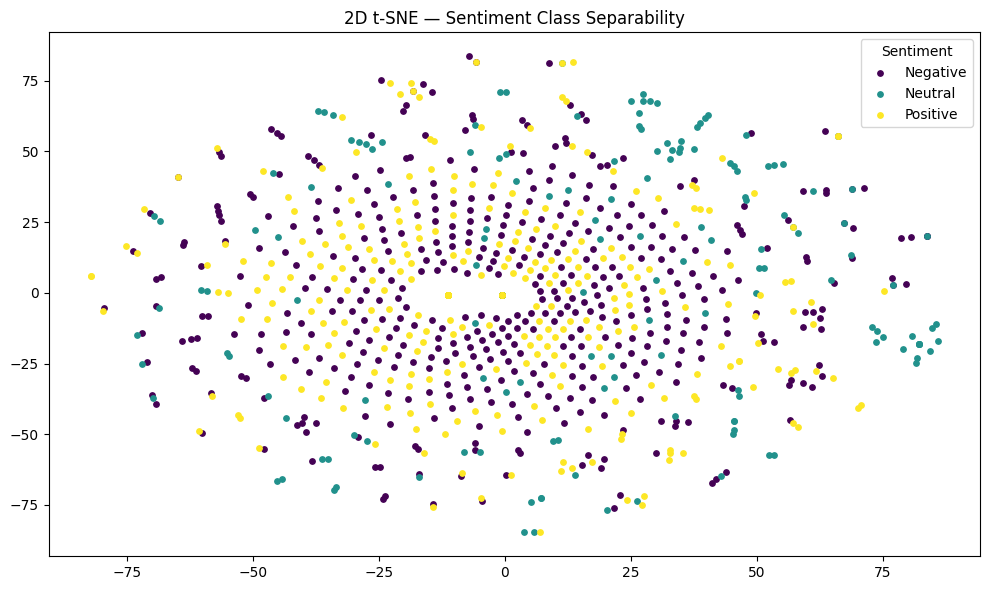

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sample_data = df_clean.sample(1000, random_state=42).copy()
X_tfidf = tfidf_check.transform(sample_data['text_processed'])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_2d = tsne.fit_transform(X_tfidf)

cmap   = plt.cm.viridis
labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
colors = {-1: cmap(0.0), 0: cmap(0.5), 1: cmap(1.0)}

plt.figure(figsize=(10, 6))
for sentiment, label in labels.items():
    mask = sample_data['sentiment'].values == sentiment
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[colors[sentiment]],
                label=label,
                s=15)

plt.title('2D t-SNE — Sentiment Class Separability')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(r".../reports/eda/tsne_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sampledf.head()

,sentiment,char_count,word_count,avg_word_len,text_processed
0,-1,168,30,4.633333,video game predatori design suck keep lock exp...
1,-1,188,33,4.727273,your paint extrem broad brush dont think scrol...
2,-1,40,7,4.857143,loldont enjoy someth get back work
3,-1,202,35,4.800000,video game addict sort media highli subject ca...
4,1,151,22,5.909091,lmao :rolling_on_the_floor_laughing: hard disa...


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Reuse the reduced features (from TruncatedSVD) or create a simple 2D t-SNE
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_2d_simple = tsne_2d.fit_transform(X_tfidf) # X_tfidf from previous cell

# 2. Create Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_2d_simple[:, 0], 
    y=X_2d_simple[:, 1], 
    hue=sample_data['sentiment'], 
    palette='Set1',
    alpha=0.7,
    s=60,
    edgecolor='w'
)

plt.title('2D t-SNE Visualization (Seaborn)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
